In [1]:
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")

PyTorch: 2.13.0+cu130
CUDA: True
GPU: NVIDIA RTX A5000 Laptop GPU
VRAM: 16.0 GB


In [2]:
from pathlib import Path

patient_dir = Path(
    r"D:\MMD\IPA Assignment\BraTS2021\BraTS2021_Training_Data\BraTS2021_00014"
)

print(patient_dir.exists())
print(list(patient_dir.iterdir()))

True
[WindowsPath('D:/MMD/IPA Assignment/BraTS2021/BraTS2021_Training_Data/BraTS2021_00014/BraTS2021_00014_flair.nii.gz'), WindowsPath('D:/MMD/IPA Assignment/BraTS2021/BraTS2021_Training_Data/BraTS2021_00014/BraTS2021_00014_seg.nii.gz'), WindowsPath('D:/MMD/IPA Assignment/BraTS2021/BraTS2021_Training_Data/BraTS2021_00014/BraTS2021_00014_t1.nii.gz'), WindowsPath('D:/MMD/IPA Assignment/BraTS2021/BraTS2021_Training_Data/BraTS2021_00014/BraTS2021_00014_t1ce.nii.gz'), WindowsPath('D:/MMD/IPA Assignment/BraTS2021/BraTS2021_Training_Data/BraTS2021_00014/BraTS2021_00014_t2.nii.gz')]


In [5]:
files = {
    "T1": patient_dir / "BraTS2021_00014_t1.nii.gz",
    "T1ce": patient_dir / "BraTS2021_00014_t1ce.nii.gz",
    "T2": patient_dir / "BraTS2021_00014_t2.nii.gz",
    "FLAIR": patient_dir / "BraTS2021_00014_flair.nii.gz",
    "SEG": patient_dir / "BraTS2021_00014_seg.nii.gz",
}

images = {}

for name, path in files.items():
    img = nib.load(path)
    images[name] = img

    print(f"{name}:")
    print("  Shape:", img.shape)
    print("  Voxel spacing:", img.header.get_zooms()[:3])
print()

T1:
  Shape: (240, 240, 155)
  Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
T1ce:
  Shape: (240, 240, 155)
  Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
T2:
  Shape: (240, 240, 155)
  Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
FLAIR:
  Shape: (240, 240, 155)
  Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
SEG:
  Shape: (240, 240, 155)
  Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))



In [6]:
img.get_fdata()

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [7]:
volumes = {}

for name, img in images.items():
    volumes[name] = img.get_fdata()

    print(f"{name}")
    print(f"  Shape: {volumes[name].shape}")
    print(f"  Min: {volumes[name].min()}")
    print(f"  Max: {volumes[name].max()}")
    print(f"  Mean: {volumes[name].mean():.2f}")
    print()

T1
  Shape: (240, 240, 155)
  Min: 0.0
  Max: 5482.0
  Mean: 335.69

T1ce
  Shape: (240, 240, 155)
  Min: 0.0
  Max: 12788.0
  Mean: 393.42

T2
  Shape: (240, 240, 155)
  Min: 0.0
  Max: 3099.0
  Mean: 116.38

FLAIR
  Shape: (240, 240, 155)
  Min: 0.0
  Max: 2347.0
  Mean: 151.46

SEG
  Shape: (240, 240, 155)
  Min: 0.0
  Max: 4.0
  Mean: 0.01



In [8]:
seg = volumes["SEG"]

unique_labels, counts = np.unique(seg, return_counts=True)

for label, count in zip(unique_labels, counts):
    print(f"Label {int(label)}: {count:,} voxels")

Label 0: 8,889,642 voxels
Label 1: 2 voxels
Label 2: 35,799 voxels
Label 4: 2,557 voxels


Middle slice: 77


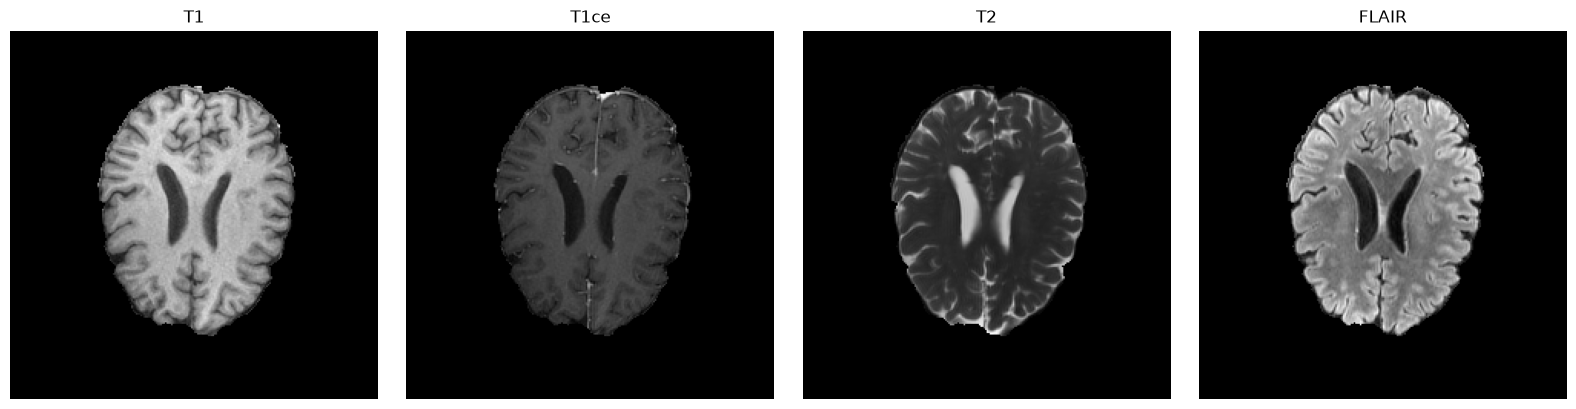

In [10]:
t1 = volumes["T1"]
t1ce = volumes["T1ce"]
t2 = volumes["T2"]
flair = volumes["FLAIR"]
z = t1.shape[2] // 2

print("Middle slice:", z)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

modalities = {
    "T1": t1,
    "T1ce": t1ce,
    "T2": t2,
    "FLAIR": flair
}

for ax, (name, volume) in zip(axes, modalities.items()):
    ax.imshow(volume[:, :, z].T, cmap="gray", origin="lower")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

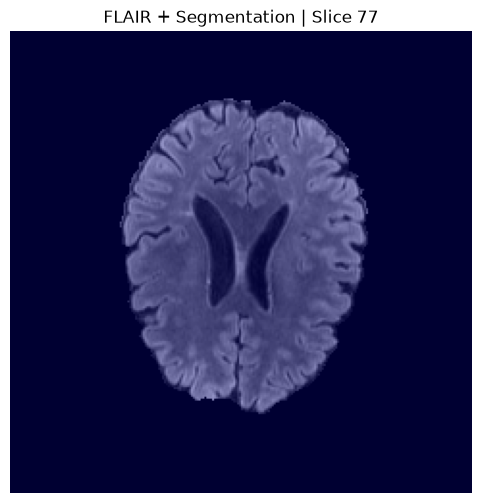

In [11]:
plt.figure(figsize=(6, 6))

plt.imshow(flair[:, :, z].T, cmap="gray", origin="lower")

plt.imshow(
    seg[:, :, z].T,
    cmap="jet",
    alpha=0.4,
    origin="lower"
)

plt.title(f"FLAIR + Segmentation | Slice {z}")
plt.axis("off")

plt.show()

In [17]:
tumor_slices = np.where(np.any(seg > 0, axis=(0, 1)))[0]

print("Tumor exists from slice:", tumor_slices.min())
print("to slice:", tumor_slices.max())
tumor_area_per_slice = np.sum(seg > 0, axis=(0, 1))

best_slice = np.argmax(tumor_area_per_slice)

print("Largest tumor slice:", best_slice)
print("Tumor voxels:", tumor_area_per_slice[best_slice])
for name, img in images.items():
    print(f"\n{name}")
    print(img.affine)

Tumor exists from slice: 13
to slice: 63
Largest tumor slice: 40
Tumor voxels: 1381

T1
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

T1ce
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

T2
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

FLAIR
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

SEG
[[ -1.  -0.  -0.  -0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]


In [23]:
for name, img in images.items():
    print(
        name,
        "| shape:", img.shape,
        "| spacing:", img.header.get_zooms()[:3]
    )

T1 | shape: (240, 240, 155) | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
T1ce | shape: (240, 240, 155) | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
T2 | shape: (240, 240, 155) | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
FLAIR | shape: (240, 240, 155) | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
SEG | shape: (240, 240, 155) | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


In [24]:
# Cross-check affine matrices across all modalities + segmentation

reference_name = "T1"
reference_affine = images[reference_name].affine

for name, img in images.items():
    is_same = np.allclose(
        reference_affine,
        img.affine,
        rtol=1e-5,
        atol=1e-5
    )

    print(f"{name}: affine matches T1 -> {is_same}")

    assert is_same, (
        f"Affine mismatch detected: {name} does not match {reference_name}"
    )

print("\n✓ All 5 volumes have consistent affine matrices.")

T1: affine matches T1 -> True
T1ce: affine matches T1 -> True
T2: affine matches T1 -> True
FLAIR: affine matches T1 -> True
SEG: affine matches T1 -> True

✓ All 5 volumes have consistent affine matrices.


In [25]:
reference_shape = images["T1"].shape
reference_spacing = images["T1"].header.get_zooms()[:3]

for name, img in images.items():
    assert img.shape == reference_shape, (
        f"Shape mismatch: {name} -> {img.shape}"
    )

    spacing = img.header.get_zooms()[:3]

    assert np.allclose(
        spacing,
        reference_spacing,
        rtol=1e-5,
        atol=1e-5
    ), (
        f"Voxel spacing mismatch: {name} -> {spacing}"
    )

print("✓ All 5 volumes have matching shape and voxel spacing.")

✓ All 5 volumes have matching shape and voxel spacing.
